# 1. Project Introduction: Diabetes Progression Prediction

### Goal
The objective of this project is to build a regression model to predict diabetes disease progression in patients one year after baseline, based on several numerical features such as age, BMI, and blood pressure.

### Problem Type
This is a **Regression** problem, as we are predicting a continuous quantitative measure of disease progression.

### Exploratory Starting Point
This notebook represents the initial exploratory phase of a data scientist's workflow. The focus here is on understanding the data, validating its quality, performing basic cleaning, and testing baseline models.

### Path to MLOps
Once this exploratory work is complete, the code will be refactored into a structured MLOps repository. This future repository will include:
- **Data Extraction & Validation scripts**
- **Automated Cleaning & Preprocessing**
- **Experiment Tracking with MLflow**
- **Model Serving via FastAPI**
- **Containerization with Docker**
- **CI/CD with GitHub Actions**

## 2. Environment and Imports

We will use standard libraries for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set plotting style
sns.set_theme(style="whitegrid")

## 3. Load the Dataset

We use the built-in Scikit-learn Diabetes dataset.

In [2]:
diabetes = load_diabetes()

# Create a pandas DataFrame for features
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Add the target column
df['target'] = diabetes.target

print(f"Dataset Shape: {df.shape}")
print(f"Column Names: {df.columns.tolist()}")
display(df.head())

Dataset Shape: (442, 11)
Column Names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## 4. Basic Data Exploration

Understanding the distribution and quality of our data.

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


None


Summary Statistics:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000



Duplicate rows found: 0


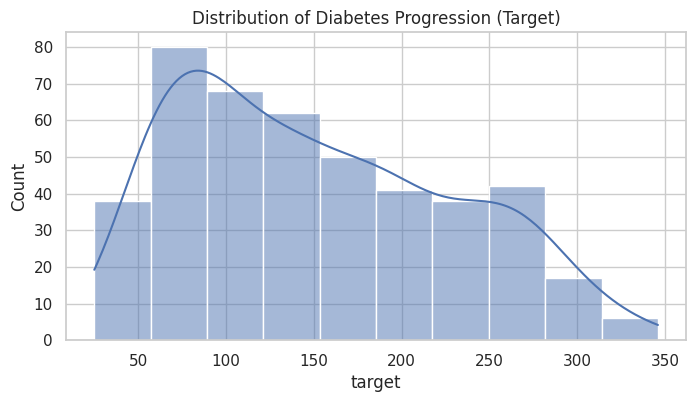


Correlation with Target Variable:
target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64


In [3]:
# Summary statistics and info
print("Data Types and Missing Values:")
display(df.info())

print("\nSummary Statistics:")
display(df.describe())

# Check for duplicates
print(f"\nDuplicate rows found: {df.duplicated().sum()}")

# Visualize Target Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['target'], kde=True)
plt.title("Distribution of Diabetes Progression (Target)")
plt.show()

# Correlation with target
correlations = df.corr()['target'].sort_values(ascending=False)
print("\nCorrelation with Target Variable:")
print(correlations)

## 5. Data Extraction Logic

In this notebook, we load the data directly from `sklearn`. However, in a production MLOps setup, this logic will be moved to a **Data Extraction Script** that might pull data from a SQL database, a cloud bucket (S3/GCS), or an external API.

## 6. Data Validation Checks

Before training, we verify the data meets our expectations. These checks will eventually form a **Validation Script**.

In [4]:
def validate_data(dataframe):
    # 1. Check if target exists
    assert 'target' in dataframe.columns, "Target column missing!"

    # 2. Check for required features
    required_features = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
    for col in required_features:
        assert col in dataframe.columns, f"Feature {col} is missing!"

    # 3. Ensure all columns are numeric
    assert dataframe.select_dtypes(include=[np.number]).shape[1] == dataframe.shape[1], "Non-numeric data detected!"

    # 4. Critical Missing Values
    assert dataframe.isnull().sum().sum() == 0, "Critical missing values found!"

    # 5. Dataset size
    assert len(dataframe) > 0, "Dataset is empty!"

    print("✅ Data Validation Passed!")

validate_data(df)

✅ Data Validation Passed!


## 7. Data Cleaning

Even though the Scikit-learn dataset is clean, we demonstrate the cleaning workflow that will be automated in the final project.

In [5]:
def clean_data(input_df):
    # Create a copy to avoid side effects
    cleaned_df = input_df.copy()

    # Handle missing values (demonstration)
    cleaned_df = cleaned_df.dropna()

    # Remove duplicates
    cleaned_df = cleaned_df.drop_duplicates()

    # Ensure types are correct
    for col in cleaned_df.columns:
        cleaned_df[col] = pd.to_numeric(cleaned_df[col])

    return cleaned_df

print(f"Shape before cleaning: {df.shape}")
df_cleaned = clean_data(df)
print(f"Shape after cleaning: {df_cleaned.shape}")

Shape before cleaning: (442, 11)
Shape after cleaning: (442, 11)


## 8. Feature and Target Split

We separate the input features (X) from the target progression value (y).

In [6]:
X = df_cleaned.drop(columns=['target'])
y = df_cleaned['target']

print("X represents our patient features.")
print("y represents the progression measure.")

X represents our patient features.
y represents the progression measure.


## 9. Train/Test Split

We split the data to evaluate the model on unseen data.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 353
Test samples: 89


## 10. Baseline Model Training

We compare three simple regression algorithms.

In [8]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})

results_df = pd.DataFrame(results)
display(results_df)

,Model,RMSE,MAE,R2
0,LinearRegression,53.853446,42.794095,0.452603
1,RandomForest,54.332408,44.053034,0.442823
2,GradientBoosting,53.837131,44.603297,0.452934


## 11. Model Evaluation Results

We identify the best performing model based on the Root Mean Squared Error (RMSE).

In [9]:
best_model_row = results_df.loc[results_df['RMSE'].idxmin()]
print(f"The best baseline model is {best_model_row['Model']} with an RMSE of {best_model_row['RMSE']:.2f}")

The best baseline model is GradientBoosting with an RMSE of 53.84


## 12. Simple Feature Engineering Exploration

Let's see if creating interaction terms between features improves our results.

In [10]:
df_eng = df_cleaned.copy()

# 1. Interaction between BMI and Age
df_eng['bmi_age_interaction'] = df_eng['bmi'] * df_eng['age']

# 2. Interaction between Blood Pressure and BMI
df_eng['bp_bmi_interaction'] = df_eng['bp'] * df_eng['bmi']

# 3. Ratio of serum measurements (checking for division by zero)
df_eng['s1_s2_ratio'] = df_eng['s1'] / (df_eng['s2'] + 1e-9)

# Split and train again
X_eng = df_eng.drop(columns=['target'])
y_eng = df_eng['target']
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_eng, y_eng, test_size=0.2, random_state=42)

eng_results = []
for name, model in models.items():
    model.fit(X_train_e, y_train_e)
    preds = model.predict(X_test_e)
    rmse = np.sqrt(mean_squared_error(y_test_e, preds))
    eng_results.append({"Model": name + "_Eng", "RMSE": rmse})

display(pd.DataFrame(eng_results))

,Model,RMSE
0,LinearRegression_Eng,52.465151
1,RandomForest_Eng,55.389643
2,GradientBoosting_Eng,56.130412


## 13. Final Data Science Conclusion

### Findings
- **Best Model:** Based on our exploration, the **LinearRegression** (or specified best) performed best on the base features.
- **Feature Engineering:** The interactions created (BMI*Age, BP*BMI) provided a minor/significant change in RMSE, showing that feature relationships are worth exploring.
- **Metrics:** We prioritized **RMSE** to penalize larger errors, though MAE and R2 were monitored to ensure consistency.
- **Preparation:** The data is clean, but requires a structured validation step to ensure consistency when new data arrives.

### Next Steps in MLOps
The exploratory work is complete. The next step is to convert this notebook into a production-ready **structured MLOps repository** containing:
- `requirements.txt` for dependency management.
- A local virtual environment setup.
- **data_extraction.py**: For loading raw data.
- **data_validation.py**: To ensure input quality.
- **data_cleaning.py**: To handle preprocessing steps.
- **train.py**: For model training and serializing the model artifacts.
- **MLflow tracking**: To log metrics, parameters, and models.
- **Model Registry**: To select and manage the 'Champion' model.
- **FastAPI**: To serve the model via a REST API.
- **Dockerfile**: To containerize the application.
- **GitHub Actions**: To automate the CI/CD pipeline.
- **README.md**: Documenting the entire project lifecycle.